# Árboles - Análisis
El objetivo de este notebook es analizar los resultados obtenidos del random search (ver `07-arboles-random_search.ipynb`) y elegir el mejor modelo para cada uno de los datasets

In [58]:
from src.model_evaluation import evaluate_models_cv
from src.utils import DEV_SET_CLEAN_NORMAL_PATH
%load_ext autoreload
%autoreload 2
import pandas as pd
from sklearn import set_config
set_config(transform_output="pandas")

from src.plots import plot_grid_search_results, plot_learning_curve, plot_cv_results
from src.pipeline import build_feature_pipeline, build_target_pipeline
from src.config import TREE_BASED_CONFIG_NORMAL
from src.utils import TARGET
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# Función para agregar una columna con un ID único para cada configuración (nos va a servir para identificar a la configuración)
def add_id_to_results(results):
    results = results.reset_index(drop=True)
    results.insert(0, 'config_id', range(1, len(results) + 1))
    return results

## 1. Dataset Normal

In [30]:
df_normal = pd.read_csv("../" + DEV_SET_CLEAN_NORMAL_PATH)

X = df_normal.drop(columns=TARGET)
y = df_normal[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

feature_pipeline = build_feature_pipeline(TREE_BASED_CONFIG_NORMAL)
target_pipeline = build_target_pipeline(TREE_BASED_CONFIG_NORMAL)

## 1.1 XGBoost Normal

In [23]:
df_xgb_normal = pd.read_csv("../results/random_search/xgb_normal.csv")
df_xgb_normal = add_id_to_results(df_xgb_normal)

In [35]:
df_xgb_normal.head()

,config_id,Unnamed: 0,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
0,1,186,0.781516,0.118025,0.032049,14,1,900,1.243571,0.846858,2536.179023,7.113218,7578.451981,86.491500,710.087251,13.094990,1434.872651,35.966782,257.164421
1,2,344,0.874963,0.012249,0.101841,13,3,1000,4.041176,0.979075,2554.034769,8.899343,7708.597657,120.544520,444.458980,4.126351,1180.497651,26.906216,474.639029
2,3,404,0.885764,0.476234,0.078018,14,4,800,1.450228,0.948566,2570.628462,3.655595,7716.860477,78.086654,534.593406,12.549669,1275.375059,35.683866,380.856747
3,4,230,0.754584,0.282221,0.067535,14,2,1000,4.974332,0.623112,2577.988132,4.383098,7506.954430,170.200532,783.716909,24.160498,1622.422651,59.204782,228.943794
4,5,373,0.972243,0.248656,0.079075,13,1,500,1.509584,0.904435,2600.656313,4.330941,7778.217663,63.736702,724.049248,11.740528,1448.428024,33.170530,259.182240


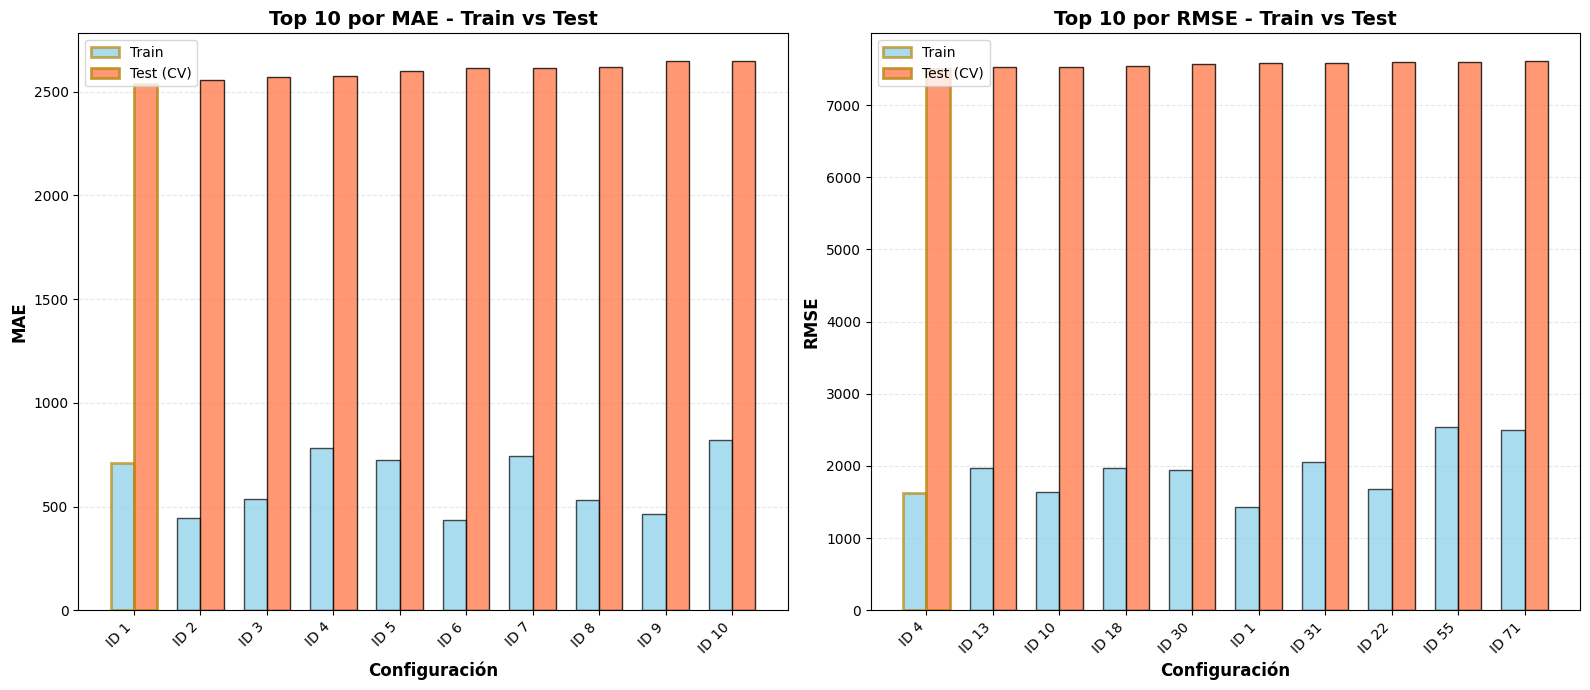

In [25]:
plot_grid_search_results(df_xgb_normal, top_n=10)

El mejor modelo es el que tiene ID 4, pero la diferencia entre train y test es enorme. Veamos su learning curve para ver si está overfiteando

In [36]:
xgb_winner_config = {
    'colsample_bytree': 0.7545843364636589,
    'gamma': 0.2822205453394412,
    'learning_rate': 0.0675347366775581,
    'max_depth': 14,
    'min_child_weight': 2,
    'n_estimators': 1000,
    'reg_lambda': 4.9743315858488355,
    'subsample': 0.6231122243985466
}

In [40]:
X_train_transformed = feature_pipeline.fit_transform(X_train)
X_val_transformed = feature_pipeline.transform(X_val)

y_train_transformed = target_pipeline.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_transformed = target_pipeline.transform(y_val.values.reshape(-1, 1)).ravel()

def eval_model(model):
    # Entrenar con eval_set para capturar learning curve
    eval_set = [(X_train_transformed, y_train_transformed),
                (X_val_transformed, y_val_transformed)]
    model.fit(
        X_train_transformed, y_train_transformed,
        eval_set=eval_set,
        verbose=False
    )

    return model.evals_result()

xgb_winner_results = eval_model(XGBRegressor(**xgb_winner_config, random_state=42))

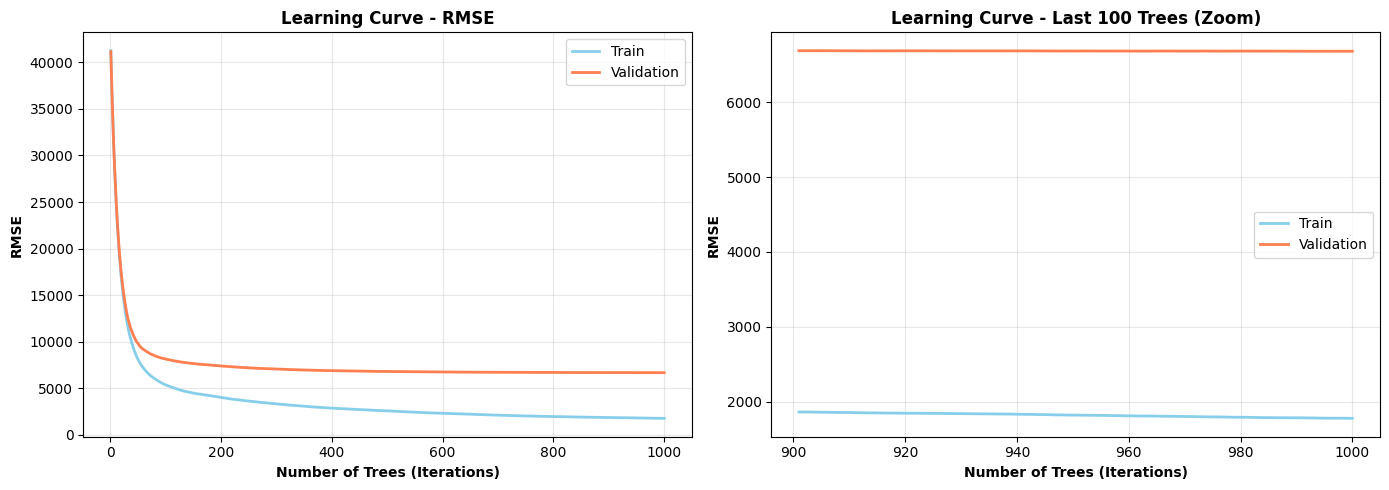


📊 RESULTADOS FINALES:
Train RMSE: 1,776.01
Val RMSE:   6,680.02
Gap: 276.1%

🎯 Early stopping óptimo: 1000 árboles
Val RMSE óptimo: 6,680.02


In [41]:
plot_learning_curve(xgb_winner_results)

Si bien el modelo no parece overfittear (la loss en val no aumenta), sí que llega un momento en el que deja de bajar (alrededor de 300 árboles). Probemos la misma configuración con 300 árboles:

In [46]:
xgb_winner_config_300 = xgb_winner_config.copy()
xgb_winner_config_300['n_estimators'] = 350
xgb_winner_results_300 = eval_model(XGBRegressor(**xgb_winner_config_300, random_state=42))

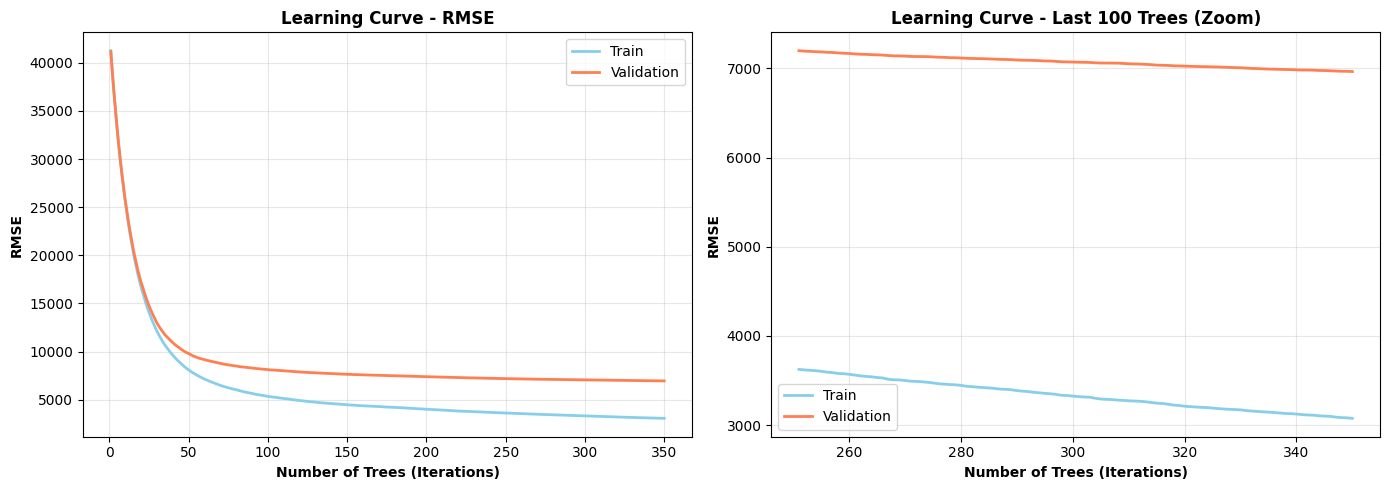


📊 RESULTADOS FINALES:
Train RMSE: 3,076.73
Val RMSE:   6,963.32
Gap: 126.3%

🎯 Early stopping óptimo: 350 árboles
Val RMSE óptimo: 6,963.32


In [47]:
plot_learning_curve(xgb_winner_results_300)

Con 350 árboles la situación mejora bastante: sube un poco el RMSE pero baja considerablemente el train. Probemos varios valores de n_estimators para encontrar el sweetspot

In [55]:
def get_winner_config_with_n_estimators(n_estimators):
    result = xgb_winner_config.copy()
    result['n_estimators'] = n_estimators
    result['random_state'] = 42
    return result


xgb_mini_gridsearch_params = {
    "100": XGBRegressor(**get_winner_config_with_n_estimators(100)),
    "150": XGBRegressor(**get_winner_config_with_n_estimators(150)),
    "200": XGBRegressor(**get_winner_config_with_n_estimators(200)),
    "250": XGBRegressor(**get_winner_config_with_n_estimators(250)),
    "300": XGBRegressor(**get_winner_config_with_n_estimators(300)),
    "350": XGBRegressor(**get_winner_config_with_n_estimators(350)),
    "400": XGBRegressor(**get_winner_config_with_n_estimators(400)),
    "450": XGBRegressor(**get_winner_config_with_n_estimators(450)),
    "500": XGBRegressor(**get_winner_config_with_n_estimators(500)),
    "1000": XGBRegressor(**get_winner_config_with_n_estimators(550)),
}

In [63]:
xgb_mini_gridsearch_results = evaluate_models_cv(xgb_mini_gridsearch_params, X_train, y_train, feature_pipeline, target_pipeline, n_splits=3)



🔄 Ejecutando 3-Fold Cross-Validation...

Entrenando 100...
  ✓ MAE: 3,575 ± 12
  ✓ RMSE: 9,768 ± 43

Entrenando 150...
  ✓ MAE: 3,398 ± 15
  ✓ RMSE: 9,371 ± 21

Entrenando 200...
  ✓ MAE: 3,291 ± 22
  ✓ RMSE: 9,162 ± 25

Entrenando 250...
  ✓ MAE: 3,210 ± 22
  ✓ RMSE: 9,026 ± 26

Entrenando 300...
  ✓ MAE: 3,142 ± 22
  ✓ RMSE: 8,923 ± 23

Entrenando 350...
  ✓ MAE: 3,087 ± 23
  ✓ RMSE: 8,842 ± 24

Entrenando 400...
  ✓ MAE: 3,041 ± 19
  ✓ RMSE: 8,781 ± 28

Entrenando 450...
  ✓ MAE: 3,004 ± 17
  ✓ RMSE: 8,741 ± 31

Entrenando 500...
  ✓ MAE: 2,974 ± 19
  ✓ RMSE: 8,711 ± 35

Entrenando 1000...
  ✓ MAE: 2,951 ± 19
  ✓ RMSE: 8,690 ± 36



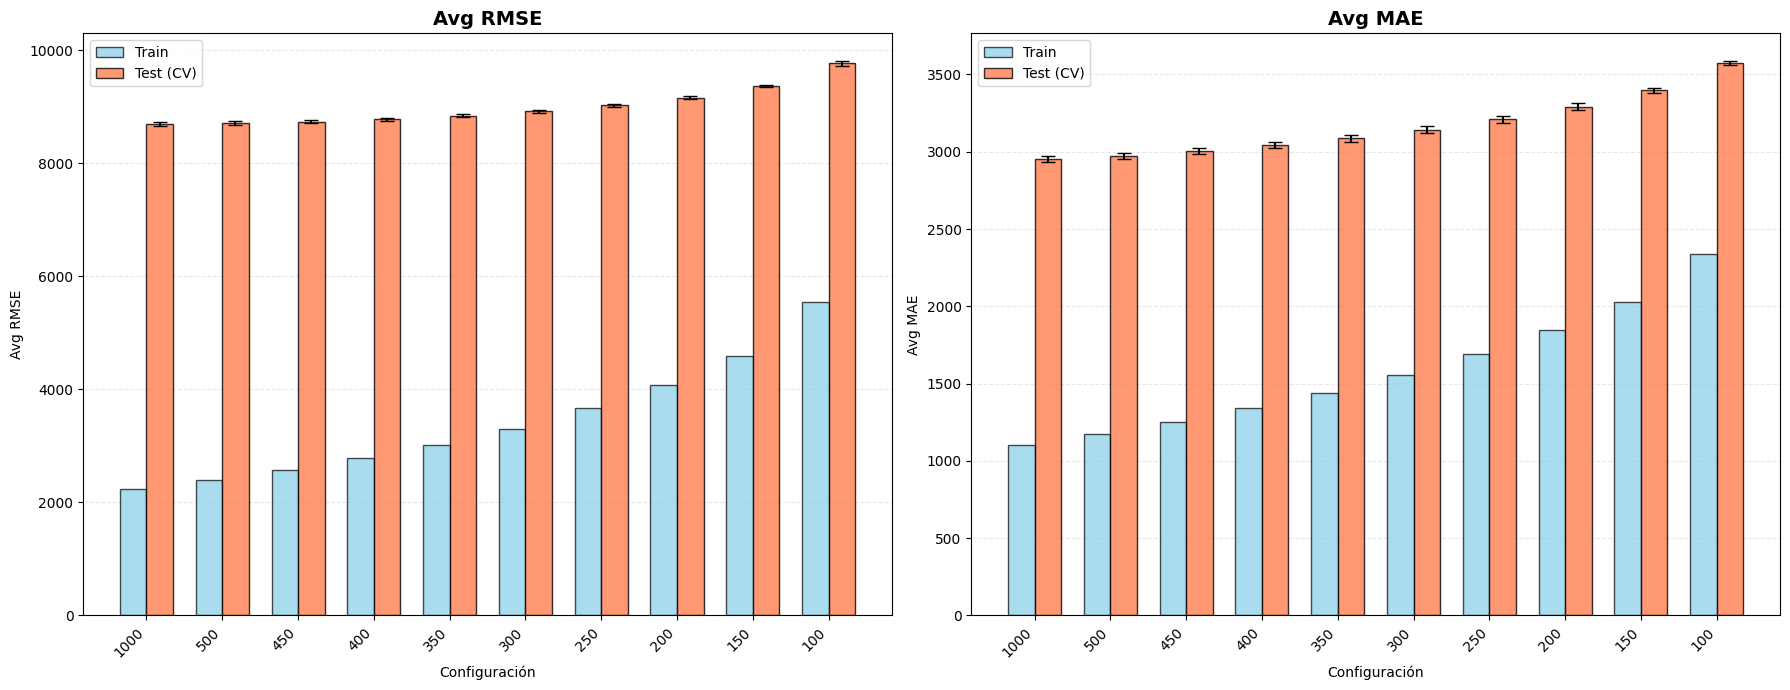

In [64]:
plot_cv_results(xgb_mini_gridsearch_results, vertical_layout=False)

## 1.2 LightGBM normal

In [60]:
df_lgbm_normal = pd.read_csv("../results/random_search/lgbm_normal.csv")
df_lgbm_normal = add_id_to_results(df_lgbm_normal)

In [61]:
df_lgbm_normal.head()

,config_id,Unnamed: 0,colsample_bytree,learning_rate,min_child_samples,min_child_weight,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
0,1,206,0.893446,0.233098,11,2.676075,1200,47,1.299066,3.801449,0.654844,3266.959748,12.630446,8115.816722,203.115698,2133.004746,12.157612,4204.854013,6.318926,53.162329
1,2,210,0.863477,0.283421,11,8.752062,1200,42,4.204358,0.192132,0.960705,3282.879378,15.609106,8149.226178,162.198427,2035.827903,10.838071,3894.974387,16.961308,61.255250
2,3,318,0.929324,0.236784,19,0.293868,1200,47,1.686728,0.096638,0.649747,3339.924916,13.888936,8222.666756,175.192574,2171.970417,14.300276,4354.730312,48.403119,53.773960
3,4,354,0.813716,0.166813,10,6.176688,1200,44,4.762336,1.133637,0.951736,3378.145397,22.035640,8286.718136,211.231516,2395.435511,7.742575,4820.745022,26.945398,41.024268
4,5,9,0.965984,0.256511,21,6.617960,1200,44,2.956489,1.373609,0.824497,3380.432346,6.452457,8315.887622,188.398544,2224.127466,15.459724,4471.706904,58.513340,51.989146


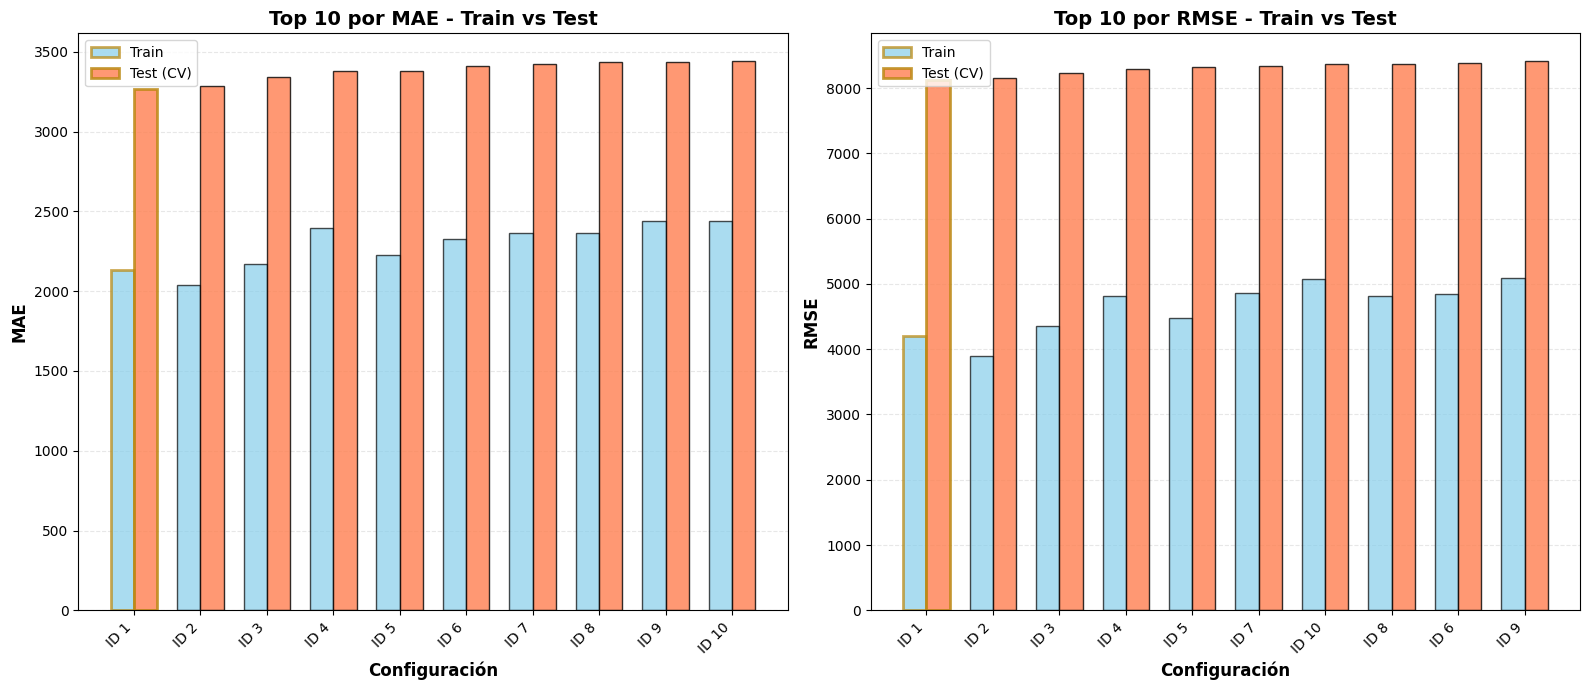

In [62]:
plot_grid_search_results(df_lgbm_normal, top_n=10)